# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()*100) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


** COMENTARIOS **

Valores nulos

La columna city presenta valores faltantes en una proporción baja, por lo que pueden mantenerse como NA o imputarse posteriormente.

Las columnas duration y length contienen nulos porque dependen del tipo de registro (llamada o mensaje), por lo que inicialmente no representan un error.

Se recomienda conservar estos valores y analizar su relación con la variable type antes de imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id, parece correcta ya que funciona como identificador.  
- La columna age, presenta el valor -999, que claramente funciona como sentinel y debe reemplazarse.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id funcionan como identificadores.
  
- La columna Duration contiene valores nulos asociados a registros de mensajes.

- La columna Length contiene valores nulos asociados a registros de llamadas.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()



city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna city contiene el valor "?" como sentinel.
- La columna plan únicamente contiene categorías válidas.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()  # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna type contiene dos categorías válidas: call y text.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  

Se identificaron valores inválidos en la columna city, donde aparece el valor "?" en 96 registros. Este valor funciona como un sentinel, ya que no representa una ciudad válida. Además, la columna ya presenta 469 valores nulos, por lo que se recomienda reemplazar "?" por NA para tratar todos los datos faltantes de forma consistente.

En las columnas plan y type no se encontraron valores inválidos. La columna plan únicamente contiene las categorías válidas "Basico" y "Premium", mientras que la columna type contiene únicamente las categorías válidas "call" y "text".

** ¿Qué acción tomarías? **

- Reemplazar el valor "?" de la columna city por valores nulos (pd.NA).
- Mantener las columnas plan y type sin modificaciones, ya que sus categorías son consistentes y válidas para el análisis.
- Continuar el proceso de limpieza utilizando la columna city ya estandarizada para evitar sesgos en futuras segmentaciones geográficas.



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(
    users['reg_date'],
    errors='coerce'
)                                # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(
    usage['date'],
    errors='coerce'
)                               # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023 y 2024, que son consistentes con el periodo de análisis. Sin embargo, también aparecen 40 registros del año 2026, lo cual representa fechas futuras respecto al límite establecido (2024). Estos registros probablemente corresponden a errores de captura y deberán marcarse como valores nulos (NaT) para evitar sesgos en el análisis.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros corresponden al año 2024, que es el periodo válido de análisis para el proyecto. No se observan fechas fuera de rango ni años futuros, por lo que la columna puede utilizarse sin necesidad de correcciones adicionales.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


** COMENTARIOS **

Las fechas deben encontrarse dentro del periodo histórico del negocio.

Fechas fuera de rango

Se identificaron 40 registros con fechas del año 2026 en la columna reg_date, equivalentes aproximadamente al 1% de los usuarios (40 de 4000 registros). Debido a que el análisis contempla información hasta 2024, estas fechas se consideran inválidas y deben marcarse como valores nulos (NaT).

En la columna date no se encontraron fechas fuera de rango, ya que el 100% de los registros pertenecen al año 2024. No es necesario realizar ninguna corrección sobre esta variable.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[
    users['age'] != -999,
    'age'
].median()

users['age'] = users['age'].replace(
    -999,
    age_mediana
)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace(
    '?',
    pd.NA
)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[
    users['reg_date'].dt.year > 2024,
    'reg_date'
] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(
    lambda x: x.isna().mean()*100
)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean()*100
)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los nulos son MAR porque dependen directamente de la variable type.

Las llamadas no tienen longitud de mensaje y los mensajes no tienen duración de llamada.

Por lo tanto, estos valores deben mantenerse como nulos y no imputarse.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(
    'user_id'
).agg({
    'is_text':'sum',
    'is_call':'sum',
    'duration':'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = [
    'user_id',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada' 
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[
     [
        'age',
        'cant_mensajes',
        'cant_llamadas',
        'cant_minutos_llamada'    
    ]
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

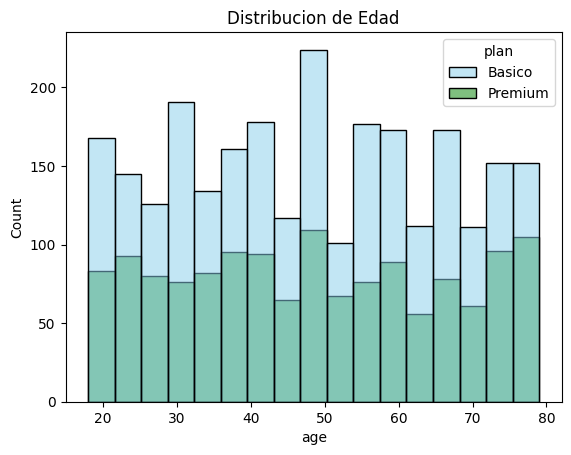

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green']    
)

plt.title('Distribucion de Edad')
plt.show()

💡Insights: 
- La distribución de edad es relativamente simétrica.
No se observan diferencias importantes entre planes.

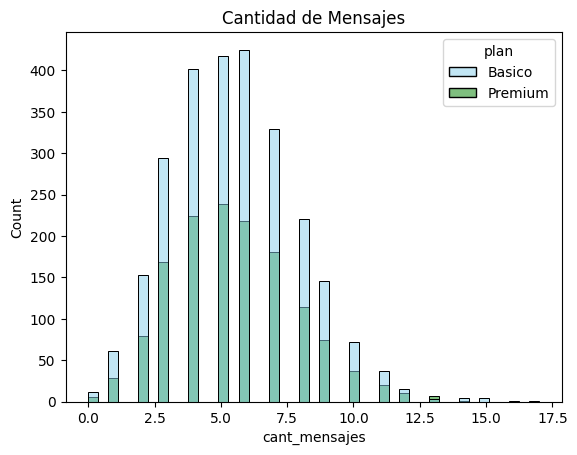

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green']    
)

plt.title('Cantidad de Mensajes')
plt.show()

💡Insights: 
- La distribución está sesgada a la derecha.
Algunos usuarios envían muchos más mensajes que el promedio.

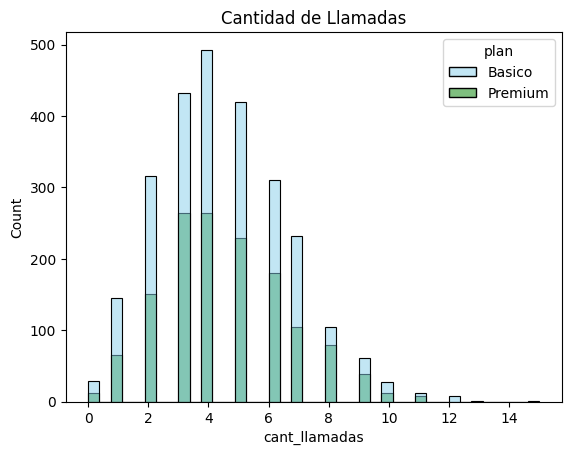

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green']    
)

plt.title('Cantidad de Llamadas')
plt.show()


💡Insights: 
- La mayoría de usuarios realiza pocas llamadas.
Existe una cola derecha con usuarios de uso intensivo.

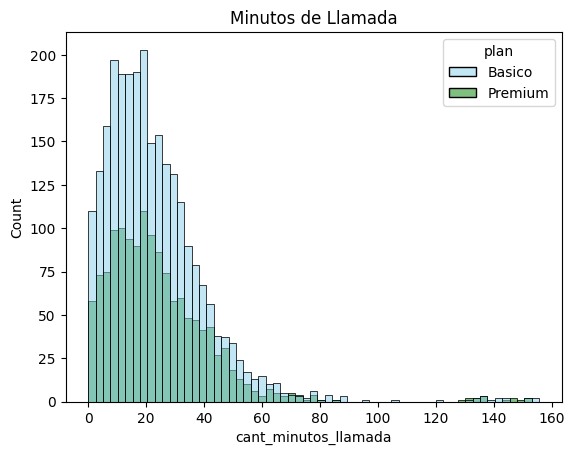

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green']    
)

plt.title('Minutos de Llamada')
plt.show()

💡Insights: 
-La distribución presenta sesgo positivo.
Algunos clientes concentran gran cantidad de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

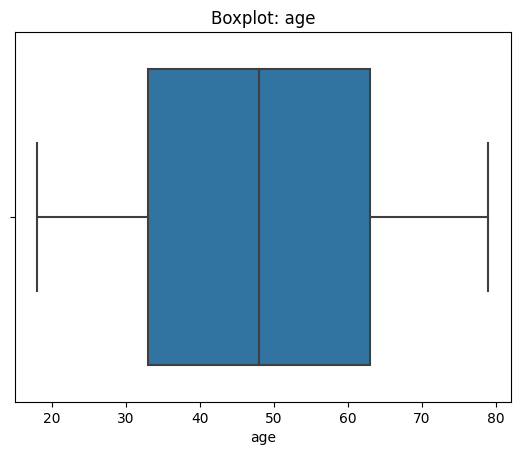

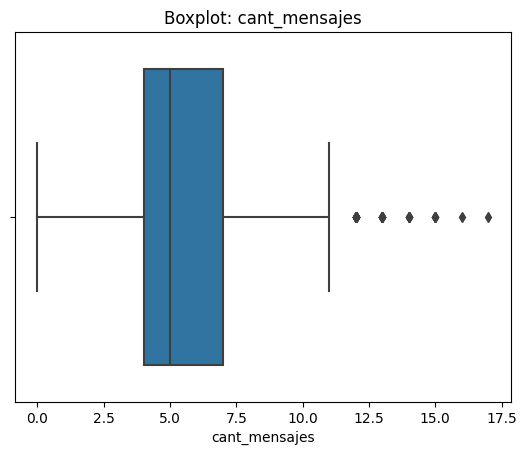

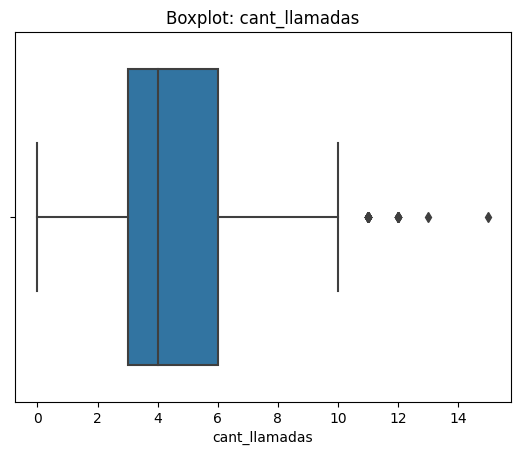

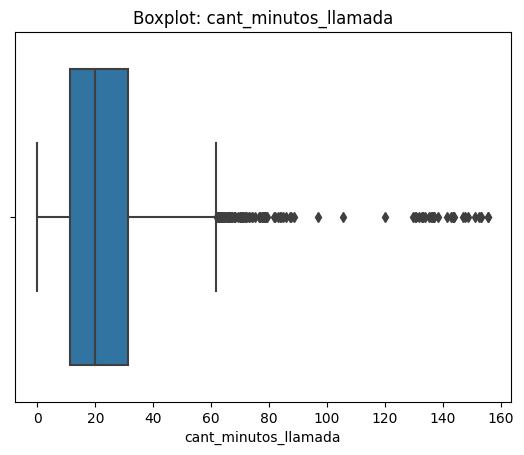

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(
        x=user_profile[col]
    )

    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: presenta pocos o ningún outlier.
- cant_mensajes: presenta outliers superiores.
- cant_llamadas: presenta outliers superiores.
- cant_minutos_llamada: presenta outliers superiores.

In [35]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(col)
    print("Limite_superior:", limite_superior)
    print("Maximo:", user_profile[col].max())
    print()



cant_mensajes
Limite_superior: 11.5
Maximo: 17.0

cant_llamadas
Limite_superior: 10.5
Maximo: 15.0

cant_minutos_llamada
Limite_superior: 61.8575
Maximo: 155.69



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener outliers porque representan usuarios intensivos reales.
- cant_llamadas: mantener outliers porque reflejan comportamiento legítimo de consumo.
- cant_minutos_llamada: mantener outliers porque son relevantes para identificar clientes de alto valor.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def grupo_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'
        

user_profile['grupo_uso'] = user_profile.apply(
    grupo_uso,
    axis=1
 )



In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
def grupo_edad(row):

    if row['age'] < 30:
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(
    grupo_edad,
    axis=1
)
        

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

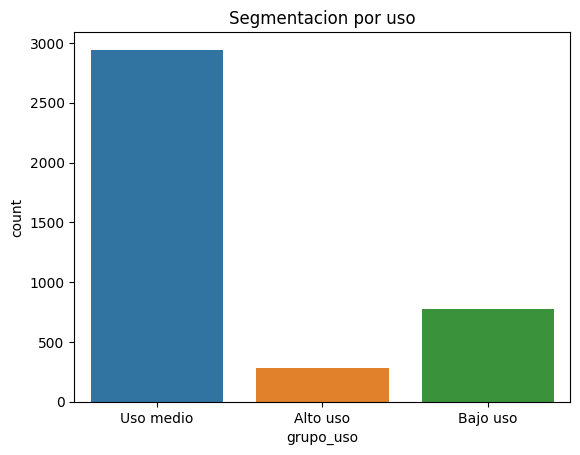

In [44]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Segmentacion por uso')
plt.show()

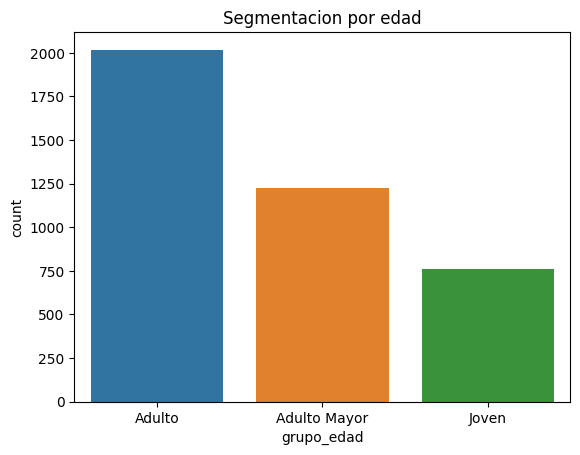

In [45]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Segmentacion por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

⚠️ Problemas detectados en los datos

Durante la etapa de calidad de datos se identificaron varios problemas que requerían limpieza antes de realizar el análisis.

La columna age contenía el valor -999, utilizado como sentinel para representar edades desconocidas. Este valor fue reemplazado por la mediana para evitar distorsionar las estadísticas.
La columna city contenía el valor "?", considerado un dato inválido. Estos registros fueron reemplazados por valores nulos (NA).
En la columna reg_date se detectaron 40 registros correspondientes al año 2026, lo que representa aproximadamente el 1% de los usuarios. Debido a que el análisis contempla información hasta 2024, estas fechas fueron marcadas como nulas.
Las columnas duration y length presentaban valores faltantes; sin embargo, se comprobó que dependen del tipo de actividad registrada (call o text), por lo que se consideraron nulos esperados y no errores de captura.

🔍 Segmentos por Edad

Se identificaron tres grupos principales de clientes:

Jóvenes (< 30 años): suelen utilizar con mayor frecuencia los servicios de mensajería y presentan un uso digital más intensivo.
Adultos (30 a 59 años): representan la mayor parte de la base de clientes y muestran un comportamiento equilibrado entre llamadas y mensajes.
Adultos Mayores (60 años o más): presentan niveles de uso más moderados y una menor actividad general.

La mayor concentración de usuarios se encuentra en el segmento Adulto, convirtiéndolo en el principal grupo objetivo para campañas comerciales.

📊 Segmentos por Nivel de Uso

La segmentación permitió clasificar a los clientes en:

Bajo uso: Usuarios con pocas llamadas y pocos mensajes.

Uso medio: Clientes con actividad regular y consumo estable de los servicios.

Alto uso: 
Usuarios que concentran la mayor cantidad de llamadas, mensajes y minutos consumidos.

Se observó que los clientes de alto uso generan una proporción importante del consumo total de la red, lo que los convierte en un segmento estratégico para la empresa.

➡️ Esto sugiere que existen necesidades diferentes entre los segmentos y que una oferta única para todos los clientes podría no ser la estrategia más eficiente.

⭐ Segmentos más valiosos para ConnectaTel

Los usuarios de alto uso, especialmente aquellos que pertenecen a planes Premium, representan el segmento más valioso debido a que:

Consumen una mayor cantidad de servicios.
Tienen más probabilidades de contratar beneficios adicionales.
Generan mayores ingresos para la compañía.
Permiten identificar oportunidades para nuevos productos y servicios.

Por otro lado, los usuarios de uso medio representan una oportunidad de crecimiento mediante campañas de migración a planes superiores.

🚨 Patrones de uso extremo (Outliers)

Se identificaron valores atípicos principalmente en:

Cantidad de mensajes enviados.
Cantidad de llamadas realizadas.
Minutos totales de llamadas.

Estos outliers se encuentran principalmente en la parte superior de la distribución y no parecen corresponder a errores de captura, sino a clientes con comportamientos de consumo intensivo.

Su presencia puede indicar:

Clientes corporativos o de alto consumo.
Usuarios con necesidades específicas de comunicación.
Posibles casos que requieren monitoreo para detectar fraude o uso inusual.

Por esta razón, se decidió mantener estos registros dentro del análisis.

💡 Recomendaciones
Crear planes diferenciados para usuarios de alto consumo, ofreciendo beneficios adicionales de llamadas y mensajes.
Diseñar estrategias de upselling para usuarios de uso medio, incentivando su migración hacia planes Premium.
Desarrollar campañas segmentadas por edad, adaptando promociones y canales de comunicación según cada grupo demográfico.
Implementar monitoreo continuo de usuarios con consumos extremos, permitiendo detectar comportamientos anómalos o posibles fraudes.
Optimizar la oferta comercial utilizando la segmentación identificada, con planes más flexibles y ajustados a las necesidades reales de los clientes.

Conclusión

El análisis permitió identificar problemas de calidad de datos, segmentar a los usuarios según edad y nivel de consumo, y detectar clientes con patrones de uso intensivo. Los resultados muestran que los usuarios de alto consumo representan una oportunidad clave para incrementar ingresos, mientras que los segmentos de uso medio pueden convertirse en clientes de mayor valor mediante estrategias comerciales específicas. Esto permitirá a ConnectaTel optimizar sus planes, mejorar la experiencia del cliente y fortalecer la retención de usuarios.




### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Se identificó el valor -999 en la columna age, utilizado como sentinel para edades desconocidas. Este valor fue reemplazado por la mediana para evitar sesgos.

-La columna city contenía el valor "?" como dato inválido. Se sustituyó por valores nulos.

-Se detectaron fechas fuera del rango permitido (posteriores a 2024), las cuales fueron marcadas como nulas.

-Las columnas duration y length presentaban valores faltantes; sin embargo, se confirmó que estos nulos dependen del tipo de registro (llamada o mensaje), por lo que se conservaron.


🔍 **Segmentos por Edad**
-La mayoría de los clientes pertenece al grupo Adulto.

-Los grupos Jóvenes y Adultos Mayores representan una menor proporción de la base de clientes. 


📊 **Segmentos por Nivel de Uso**
-Se identificaron usuarios de Bajo uso, Uso medio y Alto uso.

-Los usuarios de Alto uso concentran la mayor cantidad de llamadas, mensajes y minutos consumidos.


➡️ Esto sugiere que existe una oportunidad para crear ofertas diferenciadas según intensidad de uso.


💡 **Recomendaciones**
-Crear planes premium orientados a usuarios de alto consumo.

-Diseñar campañas de migración para usuarios de uso medio que puedan aumentar su consumo.

-Implementar monitoreo continuo sobre usuarios con consumo extremadamente alto para detectar fraude o comportamientos anómalos.

-Utilizar la segmentación por edad para personalizar promociones y mejorar la retención de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`